In [2]:
import concurrent
import time
import re

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pyvo
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS

# Suppress logging temporarily to prevent astropy
# from repeatedly printing out warning notices related to alternate WCSs
import logging

logging.getLogger("astropy").setLevel(logging.ERROR)

In [3]:
import site, glob, os
paths=[]
for sp in site.getsitepackages():
    paths += glob.glob(os.path.join(sp, "nvidia", "*", "lib"))
print(":".join(paths))

print(os.environ["LD_LIBRARY_PATH"])
os.environ["LD_LIBRARY_PATH"] = ":".join(paths)

/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/nvjitlink/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/nccl/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_runtime/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_cupti/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cuda_cccl/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cublas/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/nvshmem/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cusparse/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cufft/lib:/home/hbahk/miniconda3/envs/spherex_gpu/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/hbahk/miniconda3/e

In [4]:
import jax
print(jax.devices())
print(jax.default_backend())

[CudaDevice(id=0), CudaDevice(id=1)]
gpu


In [5]:
cutout_size = 6.15 * 15 * u.arcsec
gra, gdec = 258.2084186 * u.deg, 64.0529535 * u.deg

gco = SkyCoord(ra=gra, dec=gdec)

output_filename = "testphot.fits"

In [18]:
# Define the service endpoint for IRSA's Table Access Protocol (TAP)
# so that we can query SPHEREx metadata tables.
service = pyvo.dal.TAPService("https://irsa.ipac.caltech.edu/TAP")

# Define a query that will search the appropriate SPHEREx metadata tables
# for spectral images that cover the chosen coordinates and match the
# specified bandpass. Return the cutout data access URL and the time of observation.
# Sort by observation time.
query = f"""
SELECT
    'https://irsa.ipac.caltech.edu/' || a.uri || '?center={gra.to(u.degree).value},{gdec.to(u.degree).value}d&size={cutout_size.to(u.degree).value}' AS uri,
    p.time_bounds_lower
FROM spherex.artifact a
JOIN spherex.plane p ON a.planeid = p.planeid
WHERE 1 = CONTAINS(POINT('ICRS', {gra.to(u.degree).value}, {gdec.to(u.degree).value}), p.poly)
ORDER BY p.time_bounds_lower
"""

# Execute the query and return as an astropy Table.
t1 = time.time()
results = service.search(query)
print("Time to do TAP query: {:2.2f} seconds.".format(time.time() - t1))
print("Number of images found: {}".format(len(results)))

Time to do TAP query: 6.53 seconds.
Number of images found: 3219


In [6]:
XX, YY = np.meshgrid(np.arange(11), np.arange(11))
ZXGRID = XX.flatten() + 1
ZYGRID = YY.flatten() + 1


def get_psf_zone_table(psf_header):
    """
    Extract the PSF zone table from the PSF extension header.
    """
    xctr = {}
    yctr = {}

    for key, val in psf_header.items():
        # Look for keys like XCTR* or YCTR*
        xm = re.match(r"(XCTR*)", key)
        if xm:
            xplane = int(key.split("_")[1])
            xctr[xplane] = val
        ym = re.match(r"(YCTR*)", key)
        if ym:
            yplane = int(key.split("_")[1])
            yctr[yplane] = val

    assert len(xctr) == len(yctr)

    tab = Table(names=["zone_id", "x", "y"], dtype=[int, float, float])
    for zone_id in xctr.keys():
        tab.add_row([zone_id, xctr[zone_id], yctr[zone_id]])

    return tab


def get_nearest_psf_zone_index(x, y, psf_zone_table):
    dist = np.sqrt((psf_zone_table["x"] - x) ** 2 + (psf_zone_table["y"] - y) ** 2)
    return psf_zone_table["zone_id"][np.argmin(dist)]


from astropy.utils.data import conf

def process_cutout(row, ra, dec, cache, timeout=3600):
    """
    Downloads the cutouts given in a row of the table including all SPHEREx images overlapping with a position.

    Parameters:
    ===========

    row : astropy.table row
        Row of a table that will be changed in place by this function. The table
        is created by the SQL TAP query.
    ra,dec : coordinates (astropy units)
        Ra and Dec coordinates (same as used for the TAP query) with attached astropy units
    cache : bool
        If set to `True`, the output of cached and the cutout processing will run faster next time.
        Turn this feature off by setting `cache = False`.
    timeout : float
        Timeout for the remote request in seconds.
    """
    with conf.set_temp('remote_timeout', timeout):
        with fits.open(row["uri"], cache=cache) as hdulist:
            # There are seven HDUs:
            # 0 contains minimal metadata in the header and no data.
            # 1 through 6 are: IMAGE, FLAGS, VARIANCE, ZODI, PSF, WCS-WAVE
            header = hdulist[1].header

            # Compute pixel coordinates corresponding to cutout position.
            spatial_wcs = WCS(header)
            x, y = spatial_wcs.world_to_pixel(
                SkyCoord(ra=ra, dec=dec, unit="deg", frame="icrs")
            )

            # Compute the original pixel positions
            crpix1a = header["CRPIX1A"]
            crpix2a = header["CRPIX2A"]
            x_orig = 1 + (x - crpix1a)
            y_orig = 1 + (y - crpix2a)
            row["X"] = x_orig
            row["Y"] = y_orig

            # save the detector array number
            row["DETECTOR"] = hdulist[1].header["DETECTOR"]

            # Compute wavelength at cutout position.
            spectral_wcs = WCS(header, fobj=hdulist, key="W")
            spectral_wcs.sip = None
            wavelength, bandpass = spectral_wcs.pixel_to_world(x, y)
            row["central_wavelength"] = wavelength.to(u.micrometer).value

            # Collect the HDUs for this cutout and append the row's cutout_index to the EXTNAME.
            hdus = []
            for hdu in hdulist[
                1:5
            ]:  # skip the primary header and append until the ZODI extension
                hdu.header["EXTNAME"] = f"{hdu.header['EXTNAME']}{row['cutout_index']}"
                hdus.append(
                    hdu.copy()
                )  # Copy so the data is available after the file is closed

            # get the PSF cube only for the PSF zones that overlap with the cutout
            psf_zone_table = get_psf_zone_table(hdulist[5].header)
            xlo, xhi = 0, hdulist[1].header["NAXIS1"]
            ylo, yhi = 0, hdulist[1].header["NAXIS2"]
            xlo_orig, xhi_orig = 1 + (xlo - crpix1a), 1 + (xhi - crpix1a)
            ylo_orig, yhi_orig = 1 + (ylo - crpix2a), 1 + (yhi - crpix2a)

            # get the PSF zone coords for the lower left and upper right corners of the cutout
            zid_ll = get_nearest_psf_zone_index(xlo_orig, ylo_orig, psf_zone_table)
            zid_ur = get_nearest_psf_zone_index(xhi_orig, yhi_orig, psf_zone_table)
            zx_ll, zy_ll = ZXGRID[zid_ll - 1], ZYGRID[zid_ll - 1]
            zx_ur, zy_ur = ZXGRID[zid_ur - 1], ZYGRID[zid_ur - 1]

            # get the zone indices for the overlapping zones
            sel = (
                (ZXGRID >= zx_ll)
                & (ZXGRID <= zx_ur)
                & (ZYGRID >= zy_ll)
                & (ZYGRID <= zy_ur)
            )

            # get the PSF cube for the overlapping zones
            psf_cube = hdulist[5].data[sel, :, :]

            # replace the PSF extension with the new PSF cube and append the new PSF extension
            hdulist[5].data = psf_cube
            hdulist[5].header["NAXIS3"] = psf_cube.shape[0]

            hdulist[5].header["EXTNAME"] = f"PSF{row['cutout_index']}"
            hdus.append(hdulist[5].copy())

            # save lookup table for the PSF zone indices
            cols = fits.ColDefs(
                [
                    fits.Column(
                        name="zone_id",
                        format="J",
                        array=psf_zone_table["zone_id"][sel],
                        unit="",
                    ),
                    fits.Column(
                        name="x", format="D", array=psf_zone_table["x"][sel], unit=""
                    ),
                    fits.Column(
                        name="y", format="D", array=psf_zone_table["y"][sel], unit=""
                    ),
                ]
            )
            psf_zone_table_hdu = fits.BinTableHDU.from_columns(cols)
            psf_zone_table_hdu.header["EXTNAME"] = f"PSF_ZONE_LOOKUP{row['cutout_index']}"
            hdus.append(psf_zone_table_hdu)

            row["hdus"] = hdus

In [ ]:
results_table_serial = results.to_table()
results_table_serial["time_bounds_lower"] = results_table_serial["time_bounds_lower"] * 100
results_table_serial["cutout_index"] = range(1, len(results_table_serial) + 1)
results_table_serial["central_wavelength"] = np.full(len(results_table_serial), np.nan)
results_table_serial["X"] = np.full(len(results_table_serial), np.nan)
results_table_serial["Y"] = np.full(len(results_table_serial), np.nan)
results_table_serial["DETECTOR"] = np.full(len(results_table_serial), np.nan)
results_table_serial["hdus"] = np.full(len(results_table_serial), None)

t1 = time.time()
for row in results_table_serial:
    process_cutout(
        row, gra, gdec, cache=True
    )  # some results give "Arrays do not overlap" error
print(
    "Time to create cutouts in serial mode: {:2.2f} minutes.".format(
        (time.time() - t1) / 60
    )
)

In [38]:
results_table_parallel = results.to_table()
results_table_parallel["cutout_index"] = range(1, len(results_table_parallel) + 1)
results_table_parallel["central_wavelength"] = np.full(
    len(results_table_parallel), np.nan
)
results_table_parallel["X"] = np.full(len(results_table_parallel), np.nan)
results_table_parallel["Y"] = np.full(len(results_table_parallel), np.nan)
results_table_parallel["DETECTOR"] = np.full(len(results_table_parallel), np.nan)
results_table_parallel["hdus"] = np.full(len(results_table_parallel), None)

t1 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=50) as executor:
    futures = [
        executor.submit(process_cutout, row, gra, gdec, True)
        for row in results_table_parallel
    ]
    concurrent.futures.wait(futures)
print(
    "Time to create cutouts in parallel mode: {:2.2f} minutes.".format(
        (time.time() - t1) / 60
    )
)

Time to create cutouts in parallel mode: 5.94 minutes.


In [39]:
results_table_parallel_copy = results_table_parallel.copy()

excluded_index = []
for i in range(len(results_table_parallel["hdus"])):
    fits_hdulist = results_table_parallel["hdus"][i]
    cutout_index = results_table_parallel["cutout_index"][i]
    if fits_hdulist is None:
        print(f"No cutout found for cutout index {cutout_index}")
        excluded_index.append(i)

results_table_parallel.remove_rows(excluded_index)

# Create a summary table HDU with renamed columns
cols = fits.ColDefs(
    [
        fits.Column(
            name="cutout_index",
            format="J",
            array=results_table_parallel["cutout_index"],
            unit="",
        ),
        fits.Column(
            name="observation_date",
            format="D",
            array=results_table_parallel["time_bounds_lower"],
            unit="d",
        ),
        fits.Column(
            name="detector",
            format="J",
            array=results_table_parallel["DETECTOR"],
            unit="",
        ),
        fits.Column(name="x", format="D", array=results_table_parallel["X"], unit=""),
        fits.Column(name="y", format="D", array=results_table_parallel["Y"], unit=""),
        fits.Column(
            name="central_wavelength",
            format="D",
            array=results_table_parallel["central_wavelength"],
            unit="um",
        ),
        fits.Column(
            name="access_url",
            format="A200",
            array=results_table_parallel["uri"],
            unit="",
        ),
    ]
)
table_hdu = fits.BinTableHDU.from_columns(cols)
table_hdu.header["EXTNAME"] = "CUTOUT_INFO"

No cutout found for cutout index 1318


In [40]:
primary_hdu = fits.PrimaryHDU()
hdulist_list = [primary_hdu, table_hdu]
for i in range(len(results_table_parallel["hdus"])):
    fits_hdulist = results_table_parallel["hdus"][i]
    cutout_index = results_table_parallel["cutout_index"][i]
    if fits_hdulist is not None:
        hdulist_list.extend(fits_hdulist)
    else:
        print(f"No cutout found for cutout index {cutout_index}")
        print("This should not happen after running the cell above")
combined_hdulist = fits.HDUList(hdulist_list)

In [42]:
# Write the final MEF
combined_hdulist.writeto(output_filename, overwrite=True)

In [43]:
summary_table = Table.read(output_filename, hdu=1)
summary_table

cutout_index,observation_date,detector,x,y,central_wavelength,access_url
,d,,,,um,
int32,float64,int32,float64,float64,float64,bytes200
1,60790.082397558,6,1854.5150766535291,1603.9896855318884,4.52867291985293,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_1D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
2,60790.082397569,3,1854.9196650672843,1617.5910652894993,1.774208824638501,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_1D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
3,60790.083889803,6,1855.8010034318509,1489.5503256805505,4.5614530635549855,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_2D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
4,60790.083889803,3,1856.3570307219702,1503.0051836671403,1.815464382083945,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_2D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
5,60790.08538206,3,1857.3063025893746,1388.4542344115848,1.8579037672693253,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_3D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
6,60790.08538206,6,1856.5425213583871,1375.0709504143954,4.59483859223839,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_3D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
7,60790.086874317,6,1856.8946624172227,1260.6157762242412,4.628289559232978,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/6/level2_2025W17_4B_0051_4D6_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"
8,60790.086874317,3,1857.8600880347394,1273.8694210026813,1.900923794377697,"https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W17_4B/l2b-v20-2025-240/3/level2_2025W17_4B_0051_4D3_spx_l2b-v20-2025-240.fits?center=258.2084186,64.0529535d&size=0.025625"


In [44]:
nbr_images = np.nanmin([10, len(summary_table)])
imgs = []
wcss = []
with fits.open(output_filename) as hdul:
    for ii in range(nbr_images):
        extname = "IMAGE{}".format(summary_table["cutout_index"][ii])
        imgs.append(hdul[extname].data)
        wcss.append(WCS(hdul[extname].header))

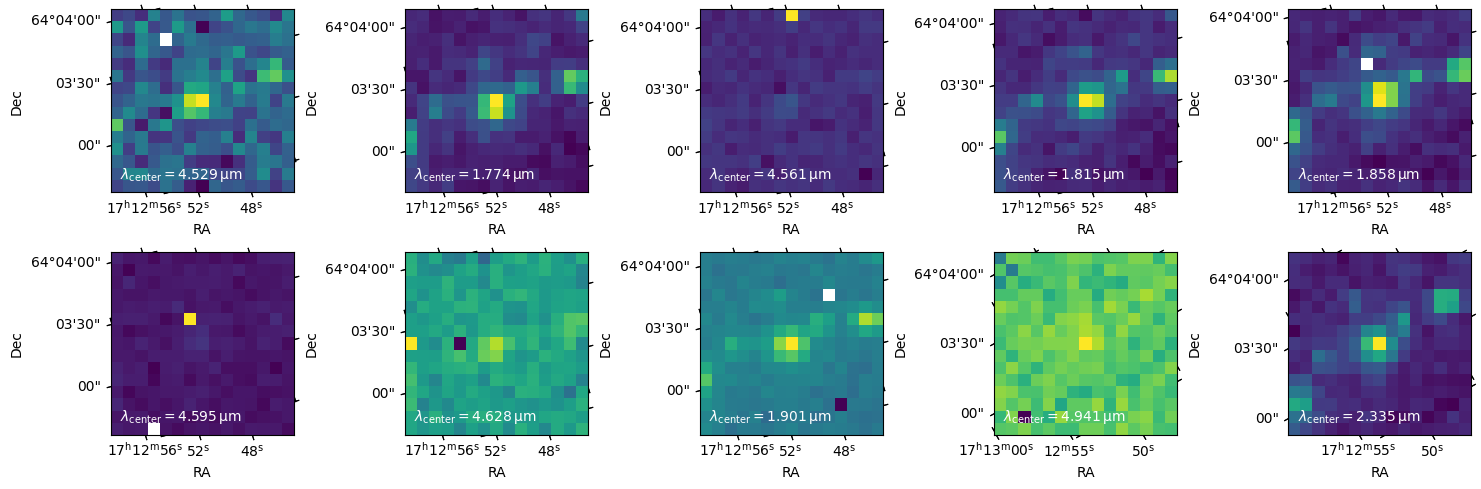

In [45]:
fig = plt.figure(figsize=(15, 5))
# axs = [fig.add_subplot(2, 5, ii + 1) for ii in range(10)]

for ii, img in enumerate(imgs):
    ax = fig.add_subplot(2, 5, ii + 1, projection=wcss[ii].celestial)
    ax.imshow(imgs[ii], norm="log", origin="lower")
    ax.text(
        0.05,
        0.05,
        r"$\lambda_{\rm center} = %2.4g \,{\rm \mu m}$"
        % summary_table["central_wavelength"][ii],
        va="bottom",
        ha="left",
        color="white",
        transform=ax.transAxes,
    )
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")

fig.tight_layout()

In [46]:
from getpass import getpass
from dl import authClient as ac, queryClient as qc, storeClient as sc
from dl.helpers.utils import convert

# get token
token = ac.login(input("Enter user name: "), getpass("Enter password: "))
print(f"Login on the data-lab - username: {ac.whoAmI()}")

schema = qc.schema("ls_dr10.tractor")
# print(schema)

Login on the data-lab - username: bahkhyeonguk


In [47]:
colnames_of_interest_ls = [
    "ls_id",
    "type",
    "ra",
    "dec",
    "flux_g",
    "flux_ivar_g",
    "flux_ivar_g",
    "flux_r",
    "flux_ivar_r",
    "flux_i",
    "flux_ivar_i",
    "flux_z",
    "flux_ivar_z",
    "flux_w1",
    "flux_ivar_w1",
    "flux_w2",
    "flux_ivar_w2",
    "mag_g",
    "mag_r",
    "mag_i",
    "mag_z",
    "sersic",
    "shape_r",
    "shape_e1",
    "shape_e2",
    "dered_flux_g",
    "dered_flux_r",
    "dered_flux_i",
    "dered_flux_z",
    "dered_flux_w1",
    "dered_flux_w2",
    "g_r",
    "r_z",
    "z_w1",
]


def async_query_ls_catalog(
    cname, cra, cdec, rlim, colnames="*", query_again=False, logger=None
):
    if colnames == "*":
        colnames_str = "*"
    else:
        colnames_str = ", ".join(colnames)

    out = f"vos://tmp/ls_{cname}.csv"

    query = f"SELECT {colnames_str} FROM ls_dr10.tractor WHERE q3c_radial_query(ra, dec, {cra}, {cdec}, {rlim})"
    if logger:
        logger.info(f"{cname} - Generated SQL query: {query}")

    try:
        jobid = qc.query(sql=query, out=out, async_=True)
        if logger:
            logger.info(f"{cname} - Query submitted. Job ID: {jobid}")
    except Exception as e:
        if logger:
            logger.error(f"An error occurred: {e} - returning None for jobid.")
        return None

    return jobid


def get_async_query_result(jobid, logger=None):
    status = qc.status(jobid)
    if status == "COMPLETED":

        res = qc.results(jobid)
        tab = convert(res, "table")
        for col in tab.colnames:
            if tab[col].dtype == "float64":
                tab[col] = tab[col].astype("float32")
        if logger:
            logger.info(f"Results retrieved for job ID: {jobid}")
        return tab
    else:
        if logger:
            logger.warning(
                f"Query for job ID: {jobid} not completed. Status: {status} - returning None."
            )
        return None

In [6]:
# query async for all clusters
name = "testgal"
rlim = cutout_size.to(u.deg).value
jobid = async_query_ls_catalog(
    name, gra.value, gdec.value, rlim, colnames_of_interest_ls
)
if jobid is not None:
    print(f"Submitted job ID: {jobid} for target: {name}")
else:
    print(f"Query for {name} failed - job ID is None.")

Submitted job ID: vyapvnbdehwcaq9t for target: testgal


In [7]:
# check status
status = qc.status(jobid)
print(f"Job ID: {jobid} for target: {name} - Status: {status}")

Job ID: vyapvnbdehwcaq9t for target: testgal - Status: COMPLETED


In [8]:
# get results
tab = get_async_query_result(jobid)
tab = tab[tab["type"] != "DUP"]
tab.write(f"ls_{name}.parquet", overwrite=True)
tab


Total time: 0.81s for 52.12 KB


ls_id,type,ra,dec,flux_g,flux_ivar_g,flux_r,flux_ivar_r,flux_i,flux_ivar_i,flux_z,flux_ivar_z,flux_w1,flux_ivar_w1,flux_w2,flux_ivar_w2,mag_g,mag_r,mag_i,mag_z,sersic,shape_r,shape_e1,shape_e2,dered_flux_g,dered_flux_r,dered_flux_i,dered_flux_z,dered_flux_w1,dered_flux_w2,g_r,r_z,z_w1
int64,str3,float32,float32,float32,float32,float32,float32,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32
9907740467660295,DEV,258.2582,64.041595,2.792252,99.57568,11.14222,33.81126,-9999,-9999,32.067883,5.52395,46.528812,2.514053,28.829798,1.153185,21.385113,19.88257,-9999,18.734825,4.0,2.068004,0.038371,0.071868,3.032423,11.779064,-9999,33.080536,46.749126,28.913555,1.502542,1.147745,0.404131
9907740467660249,PSF,258.25333,64.04283,15.399517,216.5679,22.51637,98.35317,-9999,-9999,26.744759,38.676476,0.393021,5.699852,-0.335298,2.336979,19.531233,19.118753,-9999,18.931904,0.0,0.0,0.0,0.0,16.719563,23.798986,-9999,27.58651,0.394876,-0.336269,0.412479,0.18685,-4.582056
9907740467660084,REX,258.2386,64.031944,0.354643,187.94604,0.780392,66.958336,-9999,-9999,1.065918,9.389067,-2.429119,6.870693,-2.849295,2.400165,23.625523,22.769218,-9999,22.43069,1.0,1.212734,0.0,0.0,0.384558,0.824146,-9999,1.098944,-2.440407,-2.857419,0.856304,0.338528,nan
9907740467660056,PSF,258.2358,64.03088,3.200817,441.37634,5.774232,182.27025,-9999,-9999,7.109165,51.10537,0.998748,5.890336,0.104008,2.255422,21.236849,20.596264,-9999,20.370453,0.0,0.0,0.0,0.0,3.470095,6.097124,-9999,7.328863,1.003378,0.104303,0.640585,0.225811,-2.130907
9907740467660242,REX,258.25287,64.03704,0.383272,481.53137,0.957861,182.80154,-9999,-9999,1.744912,39.851593,2.920644,3.946035,3.61186,1.712913,23.541233,22.546743,-9999,21.895567,1.0,0.28447,0.0,0.0,0.416038,1.012281,-9999,1.799688,2.934393,3.622293,0.99449,0.651176,0.559263
9907740467660248,DEV,258.25327,64.03826,1.638509,199.44888,11.286419,60.247475,-9999,-9999,25.357185,14.550554,66.35139,1.376964,38.000404,0.722447,21.963879,19.86861,-9999,18.989748,4.0,0.944151,0.142664,0.226019,1.778701,11.928156,-9999,26.15382,66.66397,38.11025,2.095268,0.878862,1.044373
9907740467660196,PSF,258.249,64.037895,0.233579,548.74615,0.350277,211.18379,-9999,-9999,-0.588278,55.84353,-0.030393,3.140855,-2.699354,1.313709,24.078917,23.638971,-9999,nan,0.0,0.0,0.0,0.0,0.253493,0.370123,-9999,-0.606696,-0.030536,-2.707131,0.439945,nan,nan
9907740467660224,PSF,258.2514,64.03939,1050.1488,0.077633,620.5652,3.834459,-9999,-9999,2765.7437,0.040823,1017.5403,0.407872,551.443,0.299805,14.946873,15.518031,-9999,13.895471,0.0,0.0,0.0,0.0,1139.9082,655.8144,-9999,2852.5469,1022.3293,553.0354,-0.571158,1.622561,-1.08565
9907740467660181,DEV,258.24698,64.04399,10.431197,51.66008,22.454803,18.506361,-9999,-9999,29.401115,3.015132,5.842449,2.727093,0.802918,1.121432,19.954165,19.121727,-9999,18.82909,4.0,4.210315,-0.29321,0.130483,11.321218,23.728067,-9999,30.322294,5.869899,0.805232,0.832438,0.292637,-1.754423


In [7]:
tab = Table.read("ls_testgal.parquet")
tco = SkyCoord(ra=tab["ra"], dec=tab["dec"], unit="deg")
sep = tco.separation(gco)
target = tab[np.argmin(sep)]
target

ls_id,type,ra,dec,flux_g,flux_ivar_g,flux_r,flux_ivar_r,flux_i,flux_ivar_i,flux_z,flux_ivar_z,flux_w1,flux_ivar_w1,flux_w2,flux_ivar_w2,mag_g,mag_r,mag_i,mag_z,sersic,shape_r,shape_e1,shape_e2,dered_flux_g,dered_flux_r,dered_flux_i,dered_flux_z,dered_flux_w1,dered_flux_w2,g_r,r_z,z_w1
int64,str3,float32,float32,float32,float32,float32,float32,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32
9907740467659773,SER,258.2084,64.052956,187.34113,18.51312,448.56924,6.199685,-9999,-9999,853.0325,2.779286,684.88245,0.524595,401.45563,0.328019,16.818417,15.870426,-9999,15.172586,4.72438,3.022533,-0.131865,0.012557,202.8886,473.31808,-9999,879.0462,688.01556,402.58252,0.94799,0.69784,-0.238374


In [8]:
import tractor
from tractor import ConstantSky, Flux, LinearPhotoCal, NullWCS, PixPos, PointSource
from tractor.galaxy import GalaxyShape
from tractor.sersic import SersicIndex, SersicGalaxy, SersicMixture
# from tractor_sphxutils import SPHERExSersicGalaxyHires, SPHERExTractorPSF
from tractor.psf import PixelizedPSF
from tractor.constrained_optimizer import ConstrainedOptimizer
from tqdm import tqdm

THAW_SHAPE = False
THAW_POSITIONS = False

PIX_SR = ((6.15 * u.arcsec)**2).to_value(u.sr)

# Bit definitions from FLAGS header
FLAG_BITS = {
    "TRANSIENT": 0,
    "OVERFLOW": 1,
    "SUR_ERROR": 2,
    "PHANTOM": 4,
    "REFERENCE": 5,
    "NONFUNC": 6,
    "DICHROIC": 7,
    "MISSING_DATA": 9,
    "HOT": 10,
    "COLD": 11,
    "FULLSAMPLE": 12,
    "PHANMISS": 14,
    "NONLINEAR": 15,
    "PERSIST": 17,
    "OUTLIER": 19,
    "SOURCE": 21,
}

MASK_FLAGS = [
    "SUR_ERROR",
    "PHANMISS",
    "NONFUNC",
    "MISSING_DATA",
    "HOT",
    "COLD",
    "PERSIST",
    "OUTLIER",
]

MASKBITS = 0
for name in MASK_FLAGS:
    MASKBITS |= (1 << FLAG_BITS[name])

print(bin(MASKBITS))

0b10100100111001000100


In [9]:
from scipy.interpolate import InterpolatedUnivariateSpline
from tractor import mixture_profiles as mp

class SPHERExSersicMixture(SersicMixture):
    singleton = None

    @staticmethod
    def getProfile(sindex):
        if SPHERExSersicMixture.singleton is None:
            SPHERExSersicMixture.singleton = SPHERExSersicMixture()
        return SPHERExSersicMixture.singleton._getProfile(sindex)

    def __init__(self):
        super().__init__()

        self.beyonds = [
            (0.29, -0.00844581249119647),
            (0.3, -0.007543589678601026),
            (0.31, -0.006720049694663777),
            (0.32, -0.0059662304247363185),
            (0.33, -0.005277313728958344),
            (0.34, -0.0046521468417414225),
            (0.35, -0.004095346709762526),
            (0.36, -0.0035988688279965375),
            (0.37, -0.0031498118023494115),
            (0.38, -0.0027583846582809324),
            (0.39, -0.002435351519089801),
            (0.4, -0.002157335977535313),
            (0.41, -0.0019076077741795316),
            (0.42, -0.0016991406639236262),
            (0.43, -0.001425029716449977),
            (0.44, -0.0012650990437518272),
            (0.45, -0.0011347785247703968),
            (0.46, -0.0009879528471214982),
            (0.47, -0.0008100151316562387),
            (0.48, -0.0005870125324175524),
            (0.49, -0.0003190764835062643),
            (0.5, 5.425903805811316e-06),
            (0.51, 0.00034705152982811294),
            (0.515, 0.0002996544861531003),
            (0.52, 0.00022447215877752225),
            (0.53, 0.00010594007072395328),
            (0.54, 0.0002694537629742144),
            (0.55, 0.0004300827684946551),
            (0.56, 0.0005944090931850887),
            (0.57, 0.0015975318101883462),
            (0.575, 0.0007583228570509637),
            (0.58, 0.0006995684031628757),
            (0.6, 0.0007162051886123733),
            (0.62, 0.0010120879777582026),
            (0.63, 0.0011267421968184088),
            (0.64, 0.0012801213226446007),
            (0.65, 0.001451646001103979),
            (0.7, 0.002508762419644761),
            (0.71, 0.002766796388286308),
            (0.72, 0.003023229882584244),
            (0.73, 0.0032915776909705485),
            (0.74, 0.003561967457950399),
            (0.75, 0.0038673532336104266),
            (0.8, 0.005528522125680335),
            (0.85, 0.007468553253350441),
            (0.9, 0.00965566942039231),
            (0.95, 0.01205320678893651),
            (1.0, 0.014659549792626902),
            (1.1, 0.017005210259315284),
            (1.2, 0.01927687860355387),
            (1.3, 0.021484300887706198),
            (1.4, 0.02363493914344006),
            (1.5, 0.025774453598841895),
            (1.55, 0.02653204147973942),
            (1.6, 0.027731530277451344),
            (1.7, 0.02997295724425736),
            (1.8, 0.031100832053232386),
            (1.9, 0.03353732320270597),
            (2.0, 0.03415553715599429),
            (2.1, 0.035866666758461396),
            (2.3, 0.03925398489658294),
            (2.5, 0.04261982372191825),
            (2.7, 0.045970050960330966),
            (3.0, 0.05097239750541088),
            (3.1, 0.05244179457571285),
            (3.2, 0.05267681959158704),
            (3.3, 0.051008278225892156),
            (3.4, 0.051581162287590465),
            (3.5, 0.052756205813684454),
            (4.0, 0.05858779172595929),
            (4.5, 0.07168299370139825),
            (5.0, 0.0841544214197475),
            (5.5, 0.09593308483544921),
            (6.0, 0.10697422593718764),
            (6.1, 0.10906657469929443),
            (6.2, 0.11117858609339415),
            (6.3, 0.1132645336487178),
        ]

        self.cores = [
            (0.29, -0.0006145669842789747),
            (0.3, -0.00047558548715020965),
            (0.31, -0.000363217224507717),
            (0.32, -0.0002860576454500885),
            (0.33, -0.0002047657848697204),
            (0.34, -0.00014498433184317872),
            (0.35, -0.00010651925123739137),
            (0.36, -8.396446125114032e-05),
            (0.37, -4.507138441234293e-05),
            (0.38, -3.380973759070649e-05),
            (0.39, -2.060885174259841e-05),
            (0.4, -1.7333510825889853e-05),
            (0.41, -1.3655362836484386e-05),
            (0.42, -2.2053831621571263e-05),
            (0.43, 3.519140248531283e-05),
            (0.44, 5.8527269772845614e-05),
            (0.45, 6.389492410741049e-05),
            (0.46, 5.951319146363376e-05),
            (0.47, 4.41916821859456e-05),
            (0.48, 2.961055933942136e-05),
            (0.49, 1.2627912384211015e-05),
            (0.5, 1.212783262150019e-07),
            (0.51, -1.9430637892225988e-05),
            (0.515, -4.212502048273059e-05),
            (0.52, -3.228734261651045e-05),
            (0.53, 7.81361399720959e-06),
            (0.54, -4.824476926845733e-07),
            (0.55, -7.352795657555866e-06),
            (0.56, -1.4297605179125483e-05),
            (0.57, -0.0008618049018462859),
            (0.575, -3.926782323415701e-06),
            (0.58, 1.862366342647581e-05),
            (0.6, 2.3501590432239983e-05),
            (0.62, 3.091940991745146e-05),
            (0.63, 1.3872692724903324e-05),
            (0.64, 8.008823279725963e-06),
            (0.65, 5.0818015268627725e-06),
            (0.7, 1.0753942212227141e-05),
            (0.71, 1.3588086665461407e-05),
            (0.72, 1.233305641651361e-05),
            (0.73, 1.1090788702317056e-05),
            (0.74, 8.221140030351126e-06),
            (0.75, 8.823047828843134e-06),
            (0.8, 1.2454565203434687e-05),
            (0.85, 1.5852421938133965e-05),
            (0.9, 2.027803646037496e-05),
            (0.95, 2.3860516997376013e-05),
            (1.0, 3.39957344719366e-05),
            (1.1, 5.54545242191784e-05),
            (1.2, 8.690513039832926e-05),
            (1.3, 0.0001277037233881062),
            (1.4, 0.0001860448049312291),
            (1.5, 0.0002658230042170695),
            (1.55, 0.00021350097227901266),
            (1.6, 0.00031839967024277493),
            (1.7, 0.0004857433537968636),
            (1.8, 0.00037686920762880494),
            (1.9, 0.0006261207533730384),
            (2.0, 0.0005666093530467542),
            (2.1, 0.0007145367012874604),
            (2.3, 0.0010893594944085816),
            (2.5, 0.0015779745432438763),
            (2.7, 0.00218967829239175),
            (3.0, 0.0033474709444939466),
            (3.1, 0.0037814734649312953),
            (3.2, 0.004189334066699302),
            (3.3, 0.0048892121748450035),
            (3.4, 0.00551991679573588),
            (3.5, 0.0060998023127743495),
            (4.0, 0.009448723687390248),
            (4.5, 0.012080413858493733),
            (5.0, 0.01499344940562819),
            (5.5, 0.018145661429931625),
            (6.0, 0.021495074522919932),
            (6.1, 0.022184349060213604),
            (6.2, 0.02288044574498377),
            (6.3, 0.02358058762144588),
        ]

        self.core_func = InterpolatedUnivariateSpline(
            [s for s, c in self.cores], [c for s, c in self.cores], k=3
        )
        self.beyond_func = InterpolatedUnivariateSpline(
            [s for s, b in self.beyonds], [b for s, b in self.beyonds], k=3
        )

    def _getProfile(self, sindex):
        matches = []
        # clamp
        if sindex <= self.lowest:
            matches.append(self.fits[0])
            sindex = self.lowest
        elif sindex >= self.highest:
            matches.append(self.fits[-1])
            sindex = self.highest
        else:
            for f in self.fits:
                lo, hi, a, v = f
                if sindex >= lo and sindex < hi:
                    matches.append(f)

        if len(matches) == 2:
            # Two ranges overlap.  Ramp between them.
            # Assume self.fits is ordered in increasing Sersic index
            m0, m1 = matches
            lo0, hi0, a0, v0 = m0
            lo1, hi1, a1, v1 = m1
            assert lo0 < lo1
            assert lo1 < hi0  # overlap is in here
            ramp_lo = lo1
            ramp_hi = hi0
            assert ramp_lo < ramp_hi
            assert ramp_lo <= sindex
            assert sindex < ramp_hi
            ramp_frac = (sindex - ramp_lo) / (ramp_hi - ramp_lo)
            amps0 = np.array([f(sindex) for f in a0])
            amps0 /= amps0.sum()
            amps1 = np.array([f(sindex) for f in a1])
            amps1 /= amps1.sum()
            amps = np.append((1.0 - ramp_frac) * amps0, ramp_frac * amps1)
            varr = np.exp(np.array([f(sindex) for f in v0 + v1]))
        else:
            assert len(matches) == 1
            lo, hi, amp_funcs, logvar_funcs = matches[0]
            amps = np.array([f(sindex) for f in amp_funcs])
            amps /= amps.sum()
            varr = np.exp(np.array([f(sindex) for f in logvar_funcs]))

        # Core
        core = self.core_func(sindex)
        beyond = self.beyond_func(sindex)
        amps *= (1.0 - core - beyond) / amps.sum()

        amps = np.append(amps, core)
        varr = np.append(varr, 0.0)

        return mp.MixtureOfGaussians(amps, np.zeros((len(amps), 2)), varr)


class SPHERExSersicGalaxy(SersicGalaxy):
    def getProfile(self):
        return SPHERExSersicMixture.getProfile(self.sersicindex.val)

In [10]:
tab = Table.read("ls_testgal.parquet")
tco = SkyCoord(ra=tab["ra"], dec=tab["dec"], unit="deg")
sep = tco.separation(gco)
main_idx = np.argmin(sep)
target = tab[main_idx]

In [11]:
def sky_pa_to_pixel_pa(wcs, ra_deg, dec_deg, pa_sky_deg, d_arcsec=1.0, y_down=False):
    """
    Convert a position angle measured on the sky (East of North basis: +x=East, +y=North)
    to a position angle in the image pixel frame (+x=right, +y=up by default).

    Parameters
    ----------
    wcs : astropy.wcs.WCS (celestial)
    ra_deg, dec_deg : float
        Target sky position in degrees (ICRS).
    pa_sky_deg : float
        Position angle on the sky in degrees, measured from +RA(East) toward +Dec(North).
        (e.g., phi = 0.5*atan2(e2,e1) in degrees)
    d_arcsec : float
        Small step used to probe local Jacobian (default 1").
    y_down : bool
        If your image/model uses +y downward (e.g., some rendering or libraries),
        set True to flip the pixel y-axis.

    Returns
    -------
    pa_pix_deg : float
        Position angle in pixel frame, measured from +x (right) toward +y (up unless y_down=True).
    """
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")

    # Base pixel
    x0, y0 = wcs.world_to_pixel(sc)

    # Unit steps on sky: +East (RA increases), +North (Dec increases)
    d = (d_arcsec * u.arcsec).to(u.deg).value
    sc_E = SkyCoord(ra=(ra_deg + d/np.cos(np.deg2rad(dec_deg)))*u.deg, dec=dec_deg*u.deg, frame="icrs")
    sc_N = SkyCoord(ra=ra_deg*u.deg, dec=(dec_deg + d)*u.deg, frame="icrs")

    xE, yE = wcs.world_to_pixel(sc_E)
    xN, yN = wcs.world_to_pixel(sc_N)

    # Pixel vectors for +East and +North at (ra,dec)
    vE = np.array([xE - x0, yE - y0])
    vN = np.array([xN - x0, yN - y0])

    # Optional: flip pixel y if your consumer uses y-down convention
    if y_down:
        vE[1] *= -1.0
        vN[1] *= -1.0

    # Sky direction unit vector in (East, North)
    th = np.deg2rad(pa_sky_deg)
    d_sky = np.array([np.cos(th), np.sin(th)])

    # Map to pixel plane via local 2x2 transform [vE vN]
    M = np.column_stack([vE, vN])  # columns are East and North in pixel basis
    v_pix = M @ d_sky

    pa_pix = np.rad2deg(np.arctan2(v_pix[1], v_pix[0]))
    return pa_pix

In [12]:
import jax
import jax.numpy as jnp
import jax.numpy.fft as jfft
import jax.image
from jax import vmap


def get_galaxy_shape_matrix(re, ab, phi):
    """
    Computes the transformation matrix G that takes unit vectors (in re)
    to degrees (intermediate world coords).

    Args:
        re: Effective radius in arcsec (scalar or array)
        ab: Axis ratio (scalar or array)
        phi: Position angle in degrees (scalar or array)

    Returns:
        G: Matrix of shape (..., 2, 2)
    """
    # Phi is E of N.
    # 0 = N (Dec increasing)
    # 90 = E (RA increasing)
    phi_rad = jnp.deg2rad(90.0 - phi)
    # HACK -- bring up to a minimum size to prevent singular matrix inversions
    # Matching tractor/galaxy.py logic
    re_deg = jnp.maximum(1.0 / 30.0, re) / 3600.0

    c = jnp.cos(phi_rad)
    s = jnp.sin(phi_rad)

    # G = re_deg * [[cp, sp * ab], [-sp, cp * ab]]
    # Shape construction
    # Note: re_deg might be scalar.

    # In tractor/galaxy.py:
    # return re_deg * np.array([[cp, sp * self.ab], [-sp, cp * self.ab]])

    # Correct stacking.
    # If re, ab, phi are scalars, we want (2, 2).
    # If arrays (N,), we want (N, 2, 2).

    row1 = jnp.stack([c, s * ab], axis=-1)
    row2 = jnp.stack([-s, c * ab], axis=-1)
    mat = jnp.stack([row1, row2], axis=-2)  # (..., 2, 2)

    G = re_deg[..., jnp.newaxis, jnp.newaxis] * mat
    return G


def get_shear_matrix(cd_inv, G):
    """
    Computes Tinv = cd_inv . G

    Args:
        cd_inv: Inverse CD matrix (..., 2, 2) (degrees -> pixels)
        G: Galaxy shape matrix (..., 2, 2) (unit re -> degrees)

    Returns:
        Tinv: Transformation matrix (..., 2, 2) (unit re -> pixels)
    """
    # Matrix multiplication
    return jnp.matmul(cd_inv, G)


def apply_shear_to_cov(cov, Tinv):
    """
    Applies shear Tinv to covariance matrix cov.
    New cov = Tinv * cov * Tinv^T

    Args:
        cov: Covariance matrices (..., K, 2, 2)
        Tinv: Shear matrices (..., 2, 2)

    Returns:
        New covariance matrices (..., K, 2, 2)
    """
    # cov is (..., K, 2, 2)
    # Tinv is (..., 2, 2) -> expand to (..., 1, 2, 2)
    Tinv_expanded = Tinv[..., jnp.newaxis, :, :]

    # matmul: (..., 1, 2, 2) @ (..., K, 2, 2) -> (..., K, 2, 2)
    # But Tinv is broadcasted over K

    # Tinv @ cov
    res = jnp.matmul(Tinv_expanded, cov)
    # res @ Tinv^T
    # Tinv^T is (..., 1, 2, 2) (transpose last two dims)
    Tinv_T = jnp.swapaxes(Tinv_expanded, -1, -2)

    new_cov = jnp.matmul(res, Tinv_T)
    return new_cov


def gaussian_fourier_transform(amp, var, mu, v, w):
    """
    Computes Fourier Transform of Mixture of Gaussians.

    Args:
        amp: Amplitudes (..., K)
        var: Variances (..., K, 2, 2)
        mu: Means (..., K, 2) (Can be None or zeros if centered)
        v: Frequencies x (..., W) or (..., W)
        w: Frequencies y (..., H)

    Returns:
        Fsum: (..., H, W) Complex array
    """
    # v, w can be 1D arrays of frequencies.
    # Let's assume v corresponds to last dim (width), w to second last (height).

    # var components
    a = var[..., 0, 0]
    b = var[..., 0, 1]
    d = var[..., 1, 1]

    # Expand dims for broadcasting
    # v: (W,) -> (1, ..., 1, 1, W)
    # w: (H,) -> (1, ..., 1, H, 1)
    # amp: (..., K) -> (..., K, 1, 1)
    # var elements: (..., K) -> (..., K, 1, 1)

    v_grid = v
    w_grid = w

    # We assume v and w are passed such that they broadcast correctly or we reshape them.
    # Usually v is (W,), w is (H,).
    # We want output (..., H, W).
    # Inputs have shape (..., K).

    # Let's add dimensions
    a = a[..., jnp.newaxis, jnp.newaxis]
    b = b[..., jnp.newaxis, jnp.newaxis]
    d = d[..., jnp.newaxis, jnp.newaxis]
    amp = amp[..., jnp.newaxis, jnp.newaxis]

    vv = v_grid**2
    ww = w_grid**2
    vw = v_grid * w_grid

    # Exponential argument (real part)
    # -2 * pi^2 * (a*v^2 + d*w^2 + 2*b*v*w)
    arg_real = -2.0 * (jnp.pi**2) * (a * vv + d * ww + 2 * b * vw)

    F = jnp.exp(arg_real)

    if mu is not None:
        mx = mu[..., 0][..., jnp.newaxis, jnp.newaxis]
        my = mu[..., 1][..., jnp.newaxis, jnp.newaxis]

        # Exponential argument (imaginary part)
        # -2 * pi * i * (mx*v + my*w)
        arg_imag = -2.0 * jnp.pi * 1j * (mx * v_grid + my * w_grid)
        F = F * jnp.exp(arg_imag)

    # Sum over K components
    Fsum = jnp.sum(amp * F, axis=-3)  # Sum over K axis (which is -3 now: ..., K, H, W)

    return Fsum


def downsample_image(img, target_shape):
    """
    Downsamples image to target_shape using Lanczos3 interpolation.
    Conserves total flux by scaling the result.

    Args:
        img: (H_hr, W_hr) image
        target_shape: (H, W) tuple

    Returns:
        (H, W) image
    """
    H_hr, W_hr = img.shape
    H, W = target_shape

    # Calculate scale factors
    scale_y = H_hr / H
    scale_x = W_hr / W

    # Resize using jax.image.resize
    # We use "lanczos3" as requested.
    out = jax.image.resize(img, target_shape, method='lanczos3')

    # Flux conservation:
    # If we downsample, the new pixel area is (scale_y * scale_x) times the old pixel area.
    # jax.image.resize interpolates intensity. To preserve total flux,
    # we need to multiply by the ratio of areas.
    # (Or effectively, we are integrating over a larger area).
    out = out * (scale_y * scale_x)

    return out


def render_galaxy_fft(
    galaxy_mix,
    psf_fft,
    shape_params,
    wcs_cd_inv,
    subpixel_offset,
    image_shape,
):
    """
    Renders a galaxy using FFT convolution.

    Args:
        galaxy_mix: (amp, mean, var) of the galaxy profile (normalized, unsheared).
        psf_fft: (H, W) Complex Fourier Transform of the PSF.
        shape_params: (re, ab, phi)
        wcs_cd_inv: (2, 2) Inverse CD matrix
        subpixel_offset: (x, y)
        image_shape: (H, W) target image shape (data pixels)

    Returns:
        Rendered image (H, W)
    """
    amp, mean, var = galaxy_mix
    re, ab, phi = shape_params
    pos_x, pos_y = subpixel_offset
    H, W = image_shape

    # 1. Compute shear matrix
    G = get_galaxy_shape_matrix(re, ab, phi)
    Tinv = get_shear_matrix(wcs_cd_inv, G)

    # 2. Shear the galaxy profile
    # Only variance changes for centered profile
    sheared_var = apply_shear_to_cov(var, Tinv)
    # Means are 0 for centered profile.
    sheared_mean = jnp.zeros_like(mean)

    # 3. Compute FFT of galaxy profile
    freq_x = jfft.rfftfreq(W)
    freq_y = jfft.fftfreq(H)

    # Meshgrid frequencies
    v_grid, w_grid = jnp.meshgrid(freq_x, freq_y)

    # Galaxy is centered at (0,0).
    # We want to shift it to (pos_x, pos_y).
    shifted_mean = sheared_mean + jnp.array([pos_x, pos_y])

    gal_fft = gaussian_fourier_transform(amp, sheared_var, shifted_mean, v_grid, w_grid)

    # 4. Multiply with PSF FFT
    # psf_fft should be rfft2 format matching (H, W)
    convolved_fft = gal_fft * psf_fft

    # 5. Inverse FFT
    img = jfft.irfft2(convolved_fft, s=(H, W))

    return img



def render_point_source_fft(flux, pos, psf_fft, image_shape):
    """
    Renders a point source using FFT convolution (phase shift).

    Args:
        flux: Scalar flux.
        pos: (x, y) Position.
        psf_fft: (H, W) FFT of PSF (centered at 0 frequency).
        image_shape: (H, W).

    Returns:
        Rendered image (H, W).
    """
    H, W = image_shape

    # Frequencies
    freq_x = jfft.rfftfreq(W)
    freq_y = jfft.fftfreq(H)

    v, w = jnp.meshgrid(freq_x, freq_y)

    # Phase shift for position
    # exp(-2pi * i * (x*v + y*w))
    phase = -2.0 * jnp.pi * 1j * (pos[0] * v + pos[1] * w)
    shift_fft = jnp.exp(phase)

    # Convolve: Multiply FFTs
    # Point source FFT is flux * shift_fft
    model_fft = flux * shift_fft * psf_fft

    # Inverse FFT
    img = jfft.irfft2(model_fft, s=(H, W))

    return img


def convolve_gaussians(amp1, mean1, var1, amp2, mean2, var2):
    """
    Convolves two MoGs.
    MoG1: (K1) components
    MoG2: (K2) components

    Args:
        amp1: (K1,)
        mean1: (K1, 2)
        var1: (K1, 2, 2)
        amp2: (K2,)
        mean2: (K2, 2)
        var2: (K2, 2, 2)

    Returns:
        (amp, mean, var) of size K1*K2
    """
    # Reshape for broadcasting
    # (K1, 1) * (1, K2) -> (K1, K2)
    new_amp = (amp1[:, jnp.newaxis] * amp2[jnp.newaxis, :]).reshape(-1)

    # (K1, 1, 2) + (1, K2, 2) -> (K1, K2, 2)
    new_mean = (mean1[:, jnp.newaxis, :] + mean2[jnp.newaxis, :, :]).reshape(-1, 2)

    # (K1, 1, 2, 2) + (1, K2, 2, 2) -> (K1, K2, 2, 2)
    new_var = (var1[:, jnp.newaxis, :, :] + var2[jnp.newaxis, :, :, :]).reshape(
        -1, 2, 2
    )

    return new_amp, new_mean, new_var


def evaluate_mog_grid(amp, mean, var, X, Y):
    """
    Evaluates MoG on a grid (X, Y).

    Args:
        amp: (K,)
        mean: (K, 2)
        var: (K, 2, 2)
        X, Y: (H, W) coordinate arrays

    Returns:
        Image (H, W)
    """
    # Stack coords: (H, W, 2)
    pos = jnp.stack([X, Y], axis=-1)

    # Expand dims for K
    # pos: (H, W, 1, 2)
    pos = pos[..., jnp.newaxis, :]

    # mean: (1, 1, K, 2)
    mu = mean[jnp.newaxis, jnp.newaxis, :, :]

    # diff: (H, W, K, 2)
    diff = pos - mu

    # var: (1, 1, K, 2, 2)
    cov = var[jnp.newaxis, jnp.newaxis, :, :, :]

    # Inverse covariance and determinant
    # We can use jnp.linalg.inv and det.
    # But for 2x2, explicit formula is faster/simpler?
    # Let's use jax.numpy.linalg for generality.

    inv_cov = jnp.linalg.inv(cov)  # (1, 1, K, 2, 2)
    det_cov = jnp.linalg.det(cov)  # (1, 1, K)

    # Mahalanobis distance
    # diff^T * inv_cov * diff
    # (H, W, K, 1, 2) @ (H, W, K, 2, 2) @ (H, W, K, 2, 1)

    # diff is (..., 2). Expand to column vector (..., 2, 1)
    diff_col = diff[..., jnp.newaxis]
    diff_row = diff[..., jnp.newaxis, :]  # (..., 1, 2)

    # inv_cov @ diff
    # (..., 2, 2) @ (..., 2, 1) -> (..., 2, 1)
    temp = jnp.matmul(inv_cov, diff_col)

    # diff^T @ temp
    # (..., 1, 2) @ (..., 2, 1) -> (..., 1, 1)
    exponent = -0.5 * jnp.matmul(diff_row, temp).squeeze((-1, -2))

    # Prefactor
    # 1 / (2*pi * sqrt(det))
    # Be careful with det sign? Cov should be positive definite.
    # Clip det for stability?
    det_cov = jnp.maximum(det_cov, 1e-12)

    norm = 1.0 / (2.0 * jnp.pi * jnp.sqrt(det_cov))

    # Gaussian values
    gauss = norm * jnp.exp(exponent)  # (H, W, K)

    # Replace nans with 0
    gauss = jnp.nan_to_num(gauss)

    # Weighted sum

    # amp is (K,).
    # gauss is (H, W, K).

    weighted_gauss = amp[jnp.newaxis, jnp.newaxis, :] * gauss

    return jnp.sum(weighted_gauss, axis=-1)


def render_galaxy_mog(galaxy_mix, psf_mix, shape_params, wcs_cd_inv, pos, image_shape):
    """
    Renders a galaxy using MoG convolution (Analytic).

    Args:
        galaxy_mix: (amp, mean, var) (normalized, unsheared)
        psf_mix: (amp, mean, var)
        shape_params: (re, ab, phi)
        wcs_cd_inv: (2, 2)
        pos: (x, y) Center position in pixels
        image_shape: (H, W)

    Returns:
        Image (H, W)
    """
    gal_amp, gal_mean, gal_var = galaxy_mix
    psf_amp, psf_mean, psf_var = psf_mix
    re, ab, phi = shape_params

    # 1. Shear Galaxy Profile
    G = get_galaxy_shape_matrix(re, ab, phi)
    Tinv = get_shear_matrix(wcs_cd_inv, G)

    # Tinv takes unit_re -> pixels.
    # We want to apply affine transform Tinv to the covariance.
    # The galaxy profile is in unit_re coords.
    # Covariance transforms as T C T^T.

    sheared_gal_var = apply_shear_to_cov(gal_var, Tinv)
    # Centered galaxy mean is 0
    sheared_gal_mean = jnp.zeros_like(gal_mean)

    # 2. Convolve with PSF
    # PSF is already in pixels.
    conv_amp, conv_mean, conv_var = convolve_gaussians(
        gal_amp, sheared_gal_mean, sheared_gal_var, psf_amp, psf_mean, psf_var
    )

    # Debug info
    # print(f"Gal Var: {sheared_gal_var}")
    # print(f"Conv Var: {conv_var}")

    # 3. Add position offset
    # conv_mean is relative to (0,0). Add pos.
    # But pos is (x, y) = (col, row).
    # Tractor means are (x, y).
    # evaluate_mog_grid expects mean as (x, y).
    # pos is from wcs.positionToPixel, so (x, y).

    final_mean = conv_mean + jnp.array(pos)

    # 4. Evaluate on grid
    H, W = image_shape
    xx, yy = jnp.meshgrid(jnp.arange(W), jnp.arange(H))
    img = evaluate_mog_grid(conv_amp, final_mean, conv_var, xx, yy)

    return img


def render_point_source_mog(flux, pos, psf_mix, image_shape):
    """
    Renders a point source with MoG PSF.

    Args:
        flux: Scalar
        pos: (x, y)
        psf_mix: (amp, mean, var)
        image_shape: (H, W)

    Returns:
        Image (H, W)
    """
    amp, mean, var = psf_mix

    # Shift mean
    final_mean = mean + jnp.array(pos)

    # Evaluate
    H, W = image_shape
    xx, yy = jnp.meshgrid(jnp.arange(W), jnp.arange(H))

    # Normalized PSF image
    img = evaluate_mog_grid(amp, final_mean, var, xx, yy)

    return flux * img


In [33]:
import jax
import jax.numpy as jnp
import jax.numpy.fft as jfft
from jax import jit, value_and_grad, vmap
import numpy as np
from functools import partial
import jax.image

from tractor.engine import Tractor
from tractor.pointsource import PointSource
from tractor.galaxy import (
    Galaxy,
    ExpGalaxy,
    DevGalaxy,
    CompositeGalaxy,
    FixedCompositeGalaxy,
)
from tractor.psf import PixelizedPSF, GaussianMixturePSF


def extract_model_data(tractor_obj, oversample_rendering=False):
    """
    Extracts all necessary data from a Tractor object for JAX optimization,
    grouping sources into batches (PointSource, Galaxy) for vectorized rendering.

    Args:
        tractor_obj: Tractor object.
        oversample_rendering: If True, handles oversampled PixelizedPSF by rendering at high resolution.

    Returns:
        images_data: list of dicts (data, invvar, psf_data, shape, ...)
        batches: dict containing batched source data.
        initial_fluxes: JAX array of all fluxes.
    """
    images = tractor_obj.images
    catalog = tractor_obj.catalog

    # 1. Extract Image Data & Precompute PSF FFTs
    images_data = []
    for img in images:
        h, w = img.shape
        data = jnp.array(img.getImage())
        invvar = jnp.array(img.getInvError()) ** 2

        # PSF Extraction
        psf = img.getPsf()
        psf_data = {}
        # We store type as an integer enum or boolean flag to avoid JAX string issues during JIT/vmap

        if isinstance(psf, PixelizedPSF):
            psf_data["type_code"] = jnp.array(0, dtype=jnp.int32)  # 0 for pixelized

            # Determine sampling
            # In tractor, psf.sampling < 1 usually means oversampling.
            # We convert this to an oversampling factor > 1.
            psf_sampling_raw = getattr(psf, "sampling", 1.0)
            if psf_sampling_raw < 1.0:
                 factor = 1.0 / psf_sampling_raw
            else:
                 factor = 1.0

            if oversample_rendering and factor > 1.0:
                # Store sampling factor (python float for static use)
                psf_data["sampling"] = float(factor)

                # Calculate high-res grid size
                # Assuming integer oversampling roughly
                factor_int = int(round(factor))
                H_hr = h * factor_int
                W_hr = w * factor_int

                # Pad in high-res grid
                ph, pw = psf.img.shape
                pad_img = jnp.zeros((H_hr, W_hr))

                # Place PSF in center
                cy, cx = H_hr // 2, W_hr // 2
                y0 = cy - ph // 2
                x0 = cx - pw // 2

                # Ensure bounds
                pad_img = pad_img.at[y0 : y0 + ph, x0 : x0 + pw].set(jnp.array(psf.img))

                # Shift to (0,0) for FFT
                pad_img = jnp.fft.ifftshift(pad_img)
                psf_data["fft"] = jfft.rfft2(pad_img)

            elif factor > 1.0 and not oversample_rendering:
                 # Downsample PSF to native resolution first
                 psf_data["sampling"] = 1.0

                 # Resize using jax.image.resize (or similar logic)
                 # We want to downsample psf.img from oversampled to native.
                 # Factor is 'factor'.
                 ph, pw = psf.img.shape
                 target_ph = int(round(ph / factor))
                 target_pw = int(round(pw / factor))

                 # Using lanczos3 resize
                 # Note: psf.img is numpy array here, but we can use jax.image.resize on it if we convert to jax array
                 img_jax = jnp.array(psf.img)

                 # Resize expects (H, W, C) or (H, W).
                 # We need to conserve flux.
                 # jax.image.resize interpolates.
                 # downsample_image logic:
                 scale_y = ph / target_ph
                 scale_x = pw / target_pw

                 resized_psf = jax.image.resize(img_jax, (target_ph, target_pw), method='lanczos3')
                 # Scale flux
                 resized_psf = resized_psf * (scale_y * scale_x)

                 # Now pad and FFT at native resolution
                 pad_img = jnp.zeros((h, w))
                 cy, cx = h // 2, w // 2
                 y0 = cy - target_ph // 2
                 x0 = cx - target_pw // 2

                 pad_img = pad_img.at[y0 : y0 + target_ph, x0 : x0 + target_pw].set(resized_psf)
                 pad_img = jnp.fft.ifftshift(pad_img)
                 psf_data["fft"] = jfft.rfft2(pad_img)

            else:
                # Standard path (sampling=1 or ignored)
                psf_data["sampling"] = 1.0

                # Precompute FFT for full image size (for FFT convolution)
                ph, pw = psf.img.shape
                pad_img = jnp.zeros((h, w))
                # Place PSF in center
                cy, cx = h // 2, w // 2
                y0 = cy - ph // 2
                x0 = cx - pw // 2
                pad_img = pad_img.at[y0 : y0 + ph, x0 : x0 + pw].set(jnp.array(psf.img))
                # Shift to (0,0) for FFT
                pad_img = jnp.fft.ifftshift(pad_img)
                psf_data["fft"] = jfft.rfft2(pad_img)

        elif isinstance(psf, GaussianMixturePSF):
            psf_data["type_code"] = jnp.array(1, dtype=jnp.int32)  # 1 for mog
            psf_data["sampling"] = 1.0
            mog = psf.mog
            psf_data["amp"] = jnp.array(mog.amp)
            psf_data["mean"] = jnp.array(mog.mean)
            psf_data["var"] = jnp.array(mog.var)
        else:
             # Unknown PSF
             psf_data["sampling"] = 1.0

        images_data.append(
            {
                "data": data,
                "invvar": invvar,
                "psf": psf_data,
                "shape": (h, w),
            }
        )

    # 2. Extract Source Data & Group into Batches
    initial_fluxes = []

    # Collectors
    ps_flux_idx = []
    ps_pos_pix = []  # (N_ps, N_img, 2)

    gal_flux_idx = []
    gal_pos_pix = []
    gal_wcs_cd_inv = []  # (N_gal, N_img, 2, 2)
    gal_shapes = []
    gal_profiles = []  # List of dicts

    flux_offset = 0

    for src in catalog:
        # Determine Type and potential Profile
        # Handle getSourceType missing
        if hasattr(src, "getSourceType"):
            src_type = src.getSourceType()
        else:
            # Fallback based on class
            if isinstance(src, PointSource):
                src_type = "PointSource"
            elif isinstance(src, Galaxy):
                src_type = "Galaxy"
            else:
                src_type = "Unknown"

        prof = None
        is_galaxy = False

        # Check if source is supported (PointSource, ExpGalaxy, DevGalaxy)
        # Skip CompositeGalaxy explicitly or handle it if possible.
        if isinstance(src, (CompositeGalaxy, FixedCompositeGalaxy)):
            print(f"Warning: Skipping CompositeGalaxy {src} in JAX optimization")
            continue

        # Flux (always extract to keep alignment)
        # Assuming src has brightness attribute (True for PointSource, Galaxy subclasses except Composite)
        if hasattr(src, "brightness"):
            br = src.brightness.getParams()
            n_flux = len(br)
            initial_fluxes.extend(br)
            f_idx = flux_offset
            flux_offset += n_flux
        else:
            print(f"Warning: Source {src} has no brightness attribute, skipping.")
            continue

        if isinstance(src, Galaxy) or hasattr(src, "getProfile"):
            is_galaxy = True
            if hasattr(src, "getProfile"):
                prof = src.getProfile()
            # If profile is None (e.g. CompositeGalaxy), we can't batch it as a single profile galaxy.
            if prof is None:
                is_galaxy = False  # Treat as unsupported for batching

        # Precompute Position & WCS for all images (only if we are going to batch it)
        if src_type == "PointSource" or (is_galaxy and prof is not None):
            pos_pix_list = []
            cd_inv_list = []

            for img in images:
                wcs = img.getWcs()
                x, y = wcs.positionToPixel(src.getPosition(), src)
                pos_pix_list.append([x, y])
                cd_inv = wcs.cdInverseAtPixel(x, y)
                cd_inv_list.append(cd_inv)

            pos_pix = np.array(pos_pix_list)  # (N_img, 2)
            cd_inv = np.array(cd_inv_list)  # (N_img, 2, 2)

            if src_type == "PointSource":
                ps_flux_idx.append(f_idx)
                ps_pos_pix.append(pos_pix)

            elif is_galaxy and prof is not None:
                # Safe to append
                gal_flux_idx.append(f_idx)
                gal_pos_pix.append(pos_pix)
                gal_wcs_cd_inv.append(cd_inv)
                gal_shapes.append(src.shape.getAllParams())

                gal_profiles.append(
                    {
                        "amp": np.array(prof.amp),
                        "mean": np.array(prof.mean),
                        "var": np.array(prof.var),
                    }
                )

    # 3. Assemble Batches with Padding
    batches = {}

    # -- Point Sources --
    if ps_flux_idx:
        batches["PointSource"] = {
            "flux_idx": jnp.array(ps_flux_idx, dtype=jnp.int32),
            "pos_pix": jnp.array(np.stack(ps_pos_pix), dtype=jnp.float32),
        }

    # -- Galaxies --
    if gal_flux_idx:
        # Zero Padding for MoG profiles
        max_K = 0
        for p in gal_profiles:
            max_K = max(max_K, len(p["amp"]))

        amp_list, mean_list, var_list = [], [], []

        for p in gal_profiles:
            K = len(p["amp"])
            pad_len = max_K - K

            amp = p["amp"]
            mean = p["mean"]
            var = p["var"]

            if pad_len > 0:
                amp = np.pad(amp, (0, pad_len), constant_values=0)
                mean = np.pad(mean, ((0, pad_len), (0, 0)), constant_values=0)
                # Pad var with identity (1.0) to avoid potential singularities in linear algebra if used
                var = np.pad(var, ((0, pad_len), (0, 0), (0, 0)), constant_values=1.0)

            amp_list.append(amp)
            mean_list.append(mean)
            var_list.append(var)

        batches["Galaxy"] = {
            "flux_idx": jnp.array(gal_flux_idx, dtype=jnp.int32),
            "pos_pix": jnp.array(np.stack(gal_pos_pix), dtype=jnp.float32),
            "wcs_cd_inv": jnp.array(np.stack(gal_wcs_cd_inv), dtype=jnp.float32),
            "shapes": jnp.array(np.stack(gal_shapes), dtype=jnp.float32),
            "profile": {
                "amp": jnp.array(np.stack(amp_list), dtype=jnp.float32),
                "mean": jnp.array(np.stack(mean_list), dtype=jnp.float32),
                "var": jnp.array(np.stack(var_list), dtype=jnp.float32),
            },
        }

    return images_data, batches, jnp.array(initial_fluxes, dtype=jnp.float32)


def render_batch_point_sources(fluxes, pos_pix, psf_data, img_shape):
    """
    Renders a batch of Point Sources.
    """
    sampling = psf_data.get("sampling", 1.0)

    if "fft" in psf_data:
        psf_fft = psf_data["fft"]

        # Prepare inputs for high-res rendering if sampling > 1
        H, W = img_shape
        if sampling > 1.0:
            factor = int(round(sampling))
            H_hr = H * factor
            W_hr = W * factor
            render_shape = (H_hr, W_hr)

            # Scale parameters
            # Position: data pixels -> high res pixels
            # Add offset to align pixel centers.
            # pos_hr = pos_lr * factor + (factor - 1) / 2.0
            pos_pix_scaled = pos_pix * sampling + (sampling - 1.0) / 2.0
        else:
            render_shape = img_shape
            pos_pix_scaled = pos_pix

        # Vmap over sources
        # Use partial to bind any static args if needed?
        # render_point_source_fft takes (flux, pos, psf_fft, image_shape)

        # NOTE: render_point_source_fft assumes image_shape is static tuple.
        # But here it is passed as argument.

        # vmap over fluxes and pos
        # psf_fft is broadcast (None)
        # image_shape is static (None) - wait, if I pass it as argument to vmap, JAX might trace it.
        # It's better to closure it or use partial.

        render_fn = vmap(partial(render_point_source_fft, image_shape=render_shape), in_axes=(0, 0, None))

        stamps = render_fn(fluxes, pos_pix_scaled, psf_fft)

        # Sum over sources
        combined_img = jnp.sum(stamps, axis=0)

        # Downsample if needed
        if sampling > 1.0:
            combined_img = downsample_image(combined_img, img_shape)

        return combined_img

    else:
        # MoG
        # Vmap over sources
        # render_point_source_mog(flux, pos, psf_mix, image_shape)
        psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])

        render_fn = vmap(partial(render_point_source_mog, image_shape=img_shape), in_axes=(0, 0, None))

        stamps = render_fn(fluxes, pos_pix, psf_mix)
        return jnp.sum(stamps, axis=0)


def render_batch_galaxies(
    fluxes, pos_pix, wcs_cd_inv, shapes, profiles, psf_data, img_shape
):
    """
    Renders a batch of Galaxies.
    """
    sampling = psf_data.get("sampling", 1.0)

    if "fft" in psf_data:
        psf_fft = psf_data["fft"]

        H, W = img_shape
        if sampling > 1.0:
            factor = int(round(sampling))
            H_hr = H * factor
            W_hr = W * factor
            render_shape = (H_hr, W_hr)

            # Scale parameters
            pos_pix_scaled = pos_pix * sampling + (sampling - 1.0) / 2.0
            wcs_cd_inv_scaled = wcs_cd_inv * sampling
        else:
            render_shape = img_shape
            pos_pix_scaled = pos_pix
            wcs_cd_inv_scaled = wcs_cd_inv

        # Unpack profiles
        # profiles is dict of (N_gal, ...)
        gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])

        # Vmap over sources
        # render_galaxy_fft(galaxy_mix, psf_fft, shape_params, wcs_cd_inv, subpixel_offset, image_shape)

        # in_axes:
        # gal_mix: (0, 0, 0)
        # psf_fft: None
        # shape_params: 0
        # wcs_cd_inv: 0
        # pos_pix: 0

        render_fn = vmap(partial(render_galaxy_fft, image_shape=render_shape), in_axes=((0, 0, 0), None, 0, 0, 0))

        stamps = render_fn(gal_mix, psf_fft, shapes, wcs_cd_inv_scaled, pos_pix_scaled)

        # Multiply by fluxes (N_gal, 1, 1) broadcast
        weighted_stamps = stamps * fluxes[:, jnp.newaxis, jnp.newaxis]

        combined_img = jnp.sum(weighted_stamps, axis=0)

        # Downsample if needed
        if sampling > 1.0:
            combined_img = downsample_image(combined_img, img_shape)

        return combined_img

    else:
        # MoG
        psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
        gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])

        render_fn = vmap(partial(render_galaxy_mog, image_shape=img_shape), in_axes=((0, 0, 0), None, 0, 0, 0))

        stamps = render_fn(gal_mix, psf_mix, shapes, wcs_cd_inv, pos_pix)

        weighted_stamps = stamps * fluxes[:, jnp.newaxis, jnp.newaxis]

        return jnp.sum(weighted_stamps, axis=0)


def render_scene(fluxes, images_data, batches):
    """
    Renders the scene for all images using batched processing.
    """
    model_images = []

    for img_idx, img_dat in enumerate(images_data):
        # Determine output shape
        # If 'data' is available, use its shape.
        if "data" in img_dat:
            H, W = img_dat["data"].shape
        elif "shape" in img_dat:
            H, W = img_dat["shape"]
        else:
            raise ValueError("Cannot determine image shape")

        img_model = jnp.zeros((H, W))

        # 1. Render Point Sources
        if "PointSource" in batches:
            batch = batches["PointSource"]
            # Get data for this image
            # pos_pix: (N_ps, N_img, 2) -> select img_idx
            pos_pix = batch["pos_pix"][:, img_idx, :]

            # Fluxes
            f_idx = batch["flux_idx"]
            batch_fluxes = fluxes[f_idx]

            ps_model = render_batch_point_sources(
                batch_fluxes, pos_pix, img_dat["psf"], (H, W)
            )
            img_model = img_model + ps_model

        # 2. Render Galaxies
        if "Galaxy" in batches:
            batch = batches["Galaxy"]
            pos_pix = batch["pos_pix"][:, img_idx, :]
            wcs_cd_inv = batch["wcs_cd_inv"][:, img_idx, :, :]
            shapes = batch["shapes"]
            profiles = batch["profile"]

            f_idx = batch["flux_idx"]
            batch_fluxes = fluxes[f_idx]

            gal_model = render_batch_galaxies(
                batch_fluxes,
                pos_pix,
                wcs_cd_inv,
                shapes,
                profiles,
                img_dat["psf"],
                (H, W),
            )
            img_model = img_model + gal_model

        model_images.append(img_model)

    return model_images


def compute_fisher_diagonal(images_data, batches, n_flux):
    """
    Computes the diagonal of the Fisher Information Matrix.
    F_ss = sum_pixels ( (dModel/dFlux_s)^2 * invvar )
    This avoids computing the full Hessian.
    """
    fisher_diag = jnp.zeros(n_flux)

    for img_idx, img_dat in enumerate(images_data):
        # Determine output shape
        if "data" in img_dat:
            H, W = img_dat["data"].shape
        elif "shape" in img_dat:
            H, W = img_dat["shape"]
        else:
            raise ValueError("Cannot determine image shape")

        invvar = img_dat["invvar"] # (H, W)

        # 1. Point Sources
        if "PointSource" in batches:
            batch = batches["PointSource"]
            pos_pix = batch["pos_pix"][:, img_idx, :] # (N_ps, 2)
            f_idx = batch["flux_idx"]

            # Unit fluxes for derivatives
            N_ps = pos_pix.shape[0]
            unit_fluxes = jnp.ones(N_ps)

            psf_data = img_dat["psf"]
            sampling = psf_data.get("sampling", 1.0)

            stamps = None

            if "fft" in psf_data:
                psf_fft = psf_data["fft"]

                if sampling > 1.0:
                    factor = int(round(sampling))
                    H_hr = H * factor
                    W_hr = W * factor
                    render_shape = (H_hr, W_hr)
                    pos_pix_scaled = pos_pix * sampling + (sampling - 1.0) / 2.0
                else:
                    render_shape = (H, W)
                    pos_pix_scaled = pos_pix

                render_fn = vmap(partial(render_point_source_fft, image_shape=render_shape), in_axes=(0, 0, None))
                stamps = render_fn(unit_fluxes, pos_pix_scaled, psf_fft) # (N_ps, H_r, W_r)

            else:
                # MoG
                psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
                render_fn = vmap(partial(render_point_source_mog, image_shape=(H, W)), in_axes=(0, 0, None))
                stamps = render_fn(unit_fluxes, pos_pix, psf_mix)

            # Downsample if needed
            if sampling > 1.0:
                 # vmap downsample
                 ds_fn = vmap(partial(downsample_image, target_shape=(H, W)))
                 stamps = ds_fn(stamps)

            # Compute contribution: sum(stamp^2 * invvar)
            contrib = jnp.sum(stamps**2 * invvar[jnp.newaxis, :, :], axis=(1, 2))
            fisher_diag = fisher_diag.at[f_idx].add(contrib)

        # 2. Galaxies
        if "Galaxy" in batches:
            batch = batches["Galaxy"]
            pos_pix = batch["pos_pix"][:, img_idx, :]
            wcs_cd_inv = batch["wcs_cd_inv"][:, img_idx, :, :]
            shapes = batch["shapes"]
            profiles = batch["profile"]
            f_idx = batch["flux_idx"]

            psf_data = img_dat["psf"]
            sampling = psf_data.get("sampling", 1.0)

            stamps = None

            if "fft" in psf_data:
                psf_fft = psf_data["fft"]
                if sampling > 1.0:
                    factor = int(round(sampling))
                    H_hr = H * factor
                    W_hr = W * factor
                    render_shape = (H_hr, W_hr)
                    pos_pix_scaled = pos_pix * sampling + (sampling - 1.0) / 2.0
                    wcs_cd_inv_scaled = wcs_cd_inv * sampling
                else:
                    render_shape = (H, W)
                    pos_pix_scaled = pos_pix
                    wcs_cd_inv_scaled = wcs_cd_inv

                gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])
                render_fn = vmap(partial(render_galaxy_fft, image_shape=render_shape), in_axes=((0, 0, 0), None, 0, 0, 0))
                stamps = render_fn(gal_mix, psf_fft, shapes, wcs_cd_inv_scaled, pos_pix_scaled)

            else:
                # MoG
                psf_mix = (psf_data["amp"], psf_data["mean"], psf_data["var"])
                gal_mix = (profiles["amp"], profiles["mean"], profiles["var"])
                render_fn = vmap(partial(render_galaxy_mog, image_shape=(H, W)), in_axes=((0, 0, 0), None, 0, 0, 0))
                stamps = render_fn(gal_mix, psf_mix, shapes, wcs_cd_inv, pos_pix)

            # Downsample
            if sampling > 1.0:
                 ds_fn = vmap(partial(downsample_image, target_shape=(H, W)))
                 stamps = ds_fn(stamps)

            contrib = jnp.sum(stamps**2 * invvar[jnp.newaxis, :, :], axis=(1, 2))
            fisher_diag = fisher_diag.at[f_idx].add(contrib)

    return fisher_diag


def solve_fluxes_core(initial_fluxes, images_data, batches, return_variances=False):
    """
    Pure JAX core optimization logic.
    Can be vmapped over batches of images/sources if data is stacked.

    Args:
        initial_fluxes: JAX array (N_flux,)
        images_data: list of dicts (for N_bands), each leaf is JAX array.
        batches: dict of batched source data (pytree leaves are JAX arrays).
        return_variances: bool, if True, calculate and return variances.

    Returns:
        optimized_fluxes: JAX array (N_flux,)
        variances: JAX array (N_flux,) (only if return_variances=True)
    """

    def loss_fn(fluxes):
        model_images = render_scene(fluxes, images_data, batches)
        chi2 = 0.0
        for i, model in enumerate(model_images):
            data = images_data[i]["data"]
            invvar = images_data[i]["invvar"]
            diff = data - model
            chi2 += jnp.sum(diff**2 * invvar)
        return chi2

    # Use Matrix-Free Newton-CG for linear least squares.
    grad_fn = jax.grad(loss_fn)
    grads = grad_fn(initial_fluxes)

    def matvec(v):
        return jax.jvp(grad_fn, (initial_fluxes,), (v,))[1]

    step, info = jax.scipy.sparse.linalg.cg(matvec, -grads, maxiter=50)

    optimized_fluxes = initial_fluxes + step

    if return_variances:
        # Compute Fisher Diagonal directly (Scalar Fisher)
        # Avoids computing full Hessian.
        fisher_diag = compute_fisher_diagonal(images_data, batches, len(initial_fluxes))

        # Variance = 1.0 / F_ss (since Hessian approx = 2 * F_ss, and Variance = 2 / Hessian)

        # Avoid division by zero
        fisher_diag = jnp.where(fisher_diag <= 0, 1e-12, fisher_diag)

        variances = 1.0 / fisher_diag

        return optimized_fluxes, variances

    return optimized_fluxes


def optimize_fluxes(tractor_obj, oversample_rendering=False, return_variances=False):
    """
    Optimizes fluxes for forced photometry using JAX.

    Args:
        tractor_obj: Tractor object with images and catalog.
        oversample_rendering: bool, if True use oversampled rendering for PixelizedPSF with sampling != 1.
        return_variances: bool, if True, return variances of fluxes.

    Returns:
        New Tractor object with optimized fluxes.
        (Optional) variances array if return_variances=True.
    """
    # 1. Precompute/Extract data
    images_data, batches, initial_fluxes = extract_model_data(tractor_obj, oversample_rendering=oversample_rendering)

    # 2. Run JAX Optimization Core
    # We use the pure function here.
    if return_variances:
        optimized_fluxes, variances = solve_fluxes_core(initial_fluxes, images_data, batches, return_variances=True)
    else:
        optimized_fluxes = solve_fluxes_core(initial_fluxes, images_data, batches, return_variances=False)

    # 3. Update Tractor object
    optimized_fluxes_np = np.array(optimized_fluxes)

    flux_idx = 0
    catalog = tractor_obj.catalog
    for src in catalog:
        # Skip sources that were skipped in extraction (Composite)
        if isinstance(src, (CompositeGalaxy, FixedCompositeGalaxy)):
            continue
        # Also ensure it has brightness
        if hasattr(src, "brightness"):
            n_flux = len(src.brightness.getParams())
            new_flux = optimized_fluxes_np[flux_idx : flux_idx + n_flux]
            src.brightness.setParams(new_flux)
            flux_idx += n_flux

    if return_variances:
        return tractor_obj, np.array(variances)

    return tractor_obj


In [14]:
# open the output file
hdul = fits.open(output_filename)

cutout_info = Table(hdul[1].data)

cutout_index = 1446

img = hdul[f"IMAGE{cutout_index}"].data
hdr = hdul[f"IMAGE{cutout_index}"].header
wcs = WCS(hdr)

flg = hdul[f"FLAGS{cutout_index}"].data
var = hdul[f"VARIANCE{cutout_index}"].data
bkg = hdul[f"ZODI{cutout_index}"].data

invvar = 1 / var
mask = flg & MASKBITS != 0
invvar[mask] = 0

psf_cube = hdul[f"PSF{cutout_index}"].data
psf_lookup = hdul[f"PSF_ZONE_LOOKUP{cutout_index}"].data

gx, gy = cutout_info["x"][cutout_index-1], cutout_info["y"][cutout_index-1]
zoneid = get_nearest_psf_zone_index(gx, gy, psf_lookup)
zidx = np.where(psf_lookup["zone_id"] == zoneid)[0][0]
psf = psf_cube[zidx]

psf_tractor = PixelizedPSF(psf, sampling=0.1)

# get the pixel coordinates of the target
tx, ty = wcs.world_to_pixel(tco)
tab["x"], tab["y"] = tx, ty

tinside = (tx > 0) & (tx < img.shape[1]) & (ty > 0) & (ty < img.shape[0])

e1, e2 = tab["shape_e1"], tab["shape_e2"]
e = np.hypot(e1, e2)
ab = (1 - e) / (1 + e)  # axis ratio = b/a
# phi = -np.rad2deg(np.arctan2(e2, e1) / 2)
phi = 0.5 * np.rad2deg(np.arctan2(e2, e1))
phi = (phi + 180.0) % 180.0


tab["shape_phi"] = phi
tab["shape_ab"] = ab


stab = tab[tinside]

tractor_source_list = []
for row in stab:
    _flux = Flux(np.random.uniform(high=1))
    if row["shape_r"] == 0:
        # _src = PointSource(PixPos(row["x"], row["y"]), Flux(row["flux_z"]))
        _src = PointSource(PixPos(row["x"], row["y"]), _flux)
    else:
        # cos = wcs.celestial.wcs.get_pc()[0, 0]
        # sin = wcs.celestial.wcs.get_pc()[1, 0]
        # angle = np.arctan2(sin, cos) * 180 / np.pi
        
        phi_img = sky_pa_to_pixel_pa(wcs, row["ra"], row["dec"], row["shape_phi"], d_arcsec=1.0, y_down=False)
        
        _src = SPHERExSersicGalaxy(
            PixPos(row["x"], row["y"]),
            # Flux(row["flux_z"]),
            _flux,
            GalaxyShape(row["shape_r"], row["shape_ab"], phi_img),
            SersicIndex(row["sersic"]),
        )

    _src.freezeAllRecursive()
    _src.thawParam("brightness")

    if row["shape_r"] > 0:
        if THAW_SHAPE:
            _src.thawPathsTo("re")
            _src.thawPathsTo("ab")
            _src.thawPathsTo("phi")

    if THAW_POSITIONS:
        _src.thawPathsTo("x")
        _src.thawPathsTo("y")

    tractor_source_list.append(_src)

tim = tractor.Image(
    data=img - bkg,
    invvar=invvar,
    psf=psf_tractor,
    wcs=NullWCS(pixscale=6.15),
    photocal=LinearPhotoCal(1.0),
    sky=ConstantSky(0.0),
)

tim.freezeAllRecursive()
# tim.thawParam("sky")
tim.thawPathsTo("sky")

trac_spherex = tractor.Tractor([tim], tractor_source_list)
# optres = trac_spherex.optimize_forced_photometry(variance=True)
# steps = 50
# dchisq = 1e-10
# for step in range(steps):
#     dlnp, _, _, var = trac_spherex.optimize(variance=True, shared_params=False)
#     if (dlnp <= dchisq) and np.all(var > 0.0):
#         break

# parnames = trac_spherex.getParamNames()
# vardict = dict(zip(parnames, var))



In [34]:
trac_spherex_jax = optimize_fluxes(trac_spherex, oversample_rendering=True, return_variances=True)

In [35]:
trac_spherex_jax

(Tractor[0.0, 0.06985379, 0.11890042, 0.045277443, 0.06265924, 0.15301986, 0.1284707, 0.14795288, 0.09692832, 0.08044259, 0.13060917, -0.12860411, 0.8897928, 0.35804692, 0.11378198, 0.15419242, 0.042256325, 0.21747512, 0.06858836, 0.06537959, 0.094991505, 0.14439979, 0.017444797, 0.124466255, 0.3430742, 0.14646533, 0.116749786, 0.27990314, 0.04882732, -0.15411323, 0.76289296, -0.021538962, -0.059225835, 0.1310128, 0.22440664, 0.09639009, 0.1362433, 0.15251479, 0.10998613, 3.4794192, 0.02017939, 0.0859624, 0.1966222, 0.21619855, 0.04759136, 0.22626346, -0.119679555, 0.21467932, 0.4000352, 0.5157718, -0.15871274, -0.037695944, 0.19805461, 0.13029596, 0.22652183, 0.09174764, 0.14571637, 0.03889452, 0.5795696, 1.2441236],
 array([0.00034813, 0.00051549, 0.00051438, 0.00028625, 0.00042533,
        0.00041869, 0.00038272, 0.00038631, 0.00059805, 0.00107006,
        0.00056407, 0.00151423, 0.0012556 , 0.00062808, 0.00068212,
        0.00051838, 0.00048421, 0.00057219, 0.00057603, 0.0005739 ,
